# Machine Learning Modeling

In [1]:
# Make sure you are at the parent directory
from pathlib import Path
import sys

# Define MODE
MODE = "COLAB" # Either "COLAB", "LOCAL", "EXPANSE"
if MODE.upper() not in ('EXPANSE', 'COLAB', 'LOCAL'):
    raise Exception("Invalid mode, the only acceptible are 'EXPANSE', 'COLAB', 'LOCAL'")
if MODE.upper() == "COLAB":
    from google.colab import drive
    drive.mount('/content/drive')

# Root path by MODE
PROJECT_ROOT_BY_MODE = {
    "COLAB": Path("/content/drive/MyDrive/DSC 288R/Project"),
    "EXPANSE": Path("/home/bguo3/bguo3/DSC-288R-Capstone-Final-Project"),
    "LOCAL": Path("/Users/steveg/Desktop/DSC-288R-Capstone-Final-Project"),
}
ROOT = PROJECT_ROOT_BY_MODE[MODE.upper()]

# Add the root path to global system
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT.resolve()))

# Print the root path
print("MODE:", MODE)
print("PROJECT_ROOT:", ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MODE: COLAB
PROJECT_ROOT: /content/drive/MyDrive/DSC 288R/Project


## Import Modules

In [2]:
from pyspark.sql import functions as F

from src.utils.pyspark_utils import create_spark_session
from src.utils.paths_utils import ProjectPaths
from src.utils.io_utils import read_spark_parquet
import src.pipelines.ML_modeling as ml

import time

## Read Train/Validation/Test Full/Sampled Dataset From Parquet

In [3]:
# Set up for Spark app & resource allocation
spark = create_spark_session("steam_reviews_machine_learning_modeling")

# Load data
paths = ProjectPaths(MODE)
if MODE.upper() == "EXPANSE":
    train = read_spark_parquet(spark=spark, path=paths.random_row_train_parquet)
    val = read_spark_parquet(spark=spark, path=paths.random_row_val_parquet)
    test = read_spark_parquet(spark=spark, path=paths.random_row_test_parquet)
else:
    train = read_spark_parquet(spark=spark, path=paths.random_row_train_sampled_parquet)
    val = read_spark_parquet(spark=spark, path=paths.random_row_val_sampled_parquet)
    test = read_spark_parquet(spark=spark, path=paths.random_row_test_sampled_parquet)

Read Spark parquet from: /content/drive/MyDrive/DSC 288R/Project/data/train_val_test_splits/random_row/train_sampled_parquet
Read Spark parquet from: /content/drive/MyDrive/DSC 288R/Project/data/train_val_test_splits/random_row/val_sampled_parquet
Read Spark parquet from: /content/drive/MyDrive/DSC 288R/Project/data/train_val_test_splits/random_row/test_sampled_parquet


## Logistic Regression Model

In [ ]:
start = time.time()

lr, lr_train_pred, lr_val_pred = ml.fit_transform_model(
    model_name ='log_reg',
    train_final_df = train,
    test_final_df = val,
    spark = spark,
    cache = True
)
ml.evaluate_model(
    model_name = 'log_reg',
    train_pred_df = lr_train_pred,
    test_pred_df = lr_val_pred,
    verbose = True
)

elapsed = time.time() - start
print(f"ML Logistic Regression took: {elapsed:.2f} seconds")

## Decision Tree Model

In [ ]:
start = time.time()

dt, dt_train_pred, dt_val_pred = ml.fit_transform_model(
    model_name ='decision_tree',
    train_final_df = train,
    test_final_df = val,
    spark = spark,
    cache = False
)
ml.evaluate_model(
    model_name= "decision_tree",
    train_pred_df= lr_train_pred,
    test_pred_df= lr_val_pred,
    verbose= True
)

elapsed = time.time() - start
print(f"ML Decision Tree took: {elapsed:.2f} seconds")

## Random Forest

In [ ]:
start = time.time()

rf, rf_train_pred, rf_val_pred = ml.fit_transform_model(
    model_name ='random_forest',
    train_final_df = train,
    test_final_df = val,
    spark = spark,
    cache = False
)
ml.evaluate_model(
    model_name= "random_forest",
    train_pred_df= rf_train_pred,
    test_pred_df= rf_val_pred,
    verbose= True
)

elapsed = time.time() - start
print(f"ML Random Forest took: {elapsed:.2f} seconds")

## Support Vector Machine Model

In [ ]:
start = time.time()

svm, svm_train_pred, svm_val_pred = ml.fit_transform_model(
    model_name ='svm',
    train_final_df = train,
    test_final_df = val,
    spark = spark,
    cache = False
)
ml.evaluate_model(
    model_name= "svm",
    train_pred_df= svm_train_pred,
    test_pred_df= svm_val_pred,
    verbose= True
)

elapsed = time.time() - start
print(f"ML Support Vector Classifier took: {elapsed:.2f} seconds")

## eXtreme Gradient Boosting Model (XGBoost)

In [16]:
start = time.time()

# Temp preprocess data to avoid XGBoost error for N class expecting class value starting at 0
xgb_train_final = train.withColumn("churn", F.col("churn").cast("int"))
xgb_val_final = val.withColumn("churn", F.col("churn").cast("int"))

xgb, xgb_train_pred, xgb_val_pred = ml.fit_transform_model(
    model_name ='xgb',
    train_final_df = train,
    test_final_df = val,
    spark = spark,
    mode = MODE
)
ml.evaluate_model(
    model_name= "xgb",
    train_pred_df= xgb_train_pred,
    test_pred_df= xgb_val_pred,
    verbose= True
)

elapsed = time.time() - start
print(f"ML XGBoost took: {elapsed:.2f} seconds")

INFO:XGBoost-PySpark:Running xgboost-3.2.0 on 1 workers with
	booster params: {'objective': 'binary:logistic', 'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.1, 'max_depth': 6, 'subsample': 0.8, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 100}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!


xgb Train areaUnderROC: 0.9927
xgb Test areaUnderROC: 0.9924



ERROR:root:KeyboardInterrupt while sending command.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/py4j/java_gateway.py", line 1038, in send_command
    response = connection.send_command(command)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/py4j/clientserver.py", line 535, in send_command
    answer = smart_decode(self.stream.readline()[:-1])
                          ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/socket.py", line 720, in readinto
    return self._sock.recv_into(b)
           ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt


KeyboardInterrupt: 

In [4]:
start = time.time()

# ------------------------------------------------------------
# 1. Train + predict + evaluate XGBoost
# ------------------------------------------------------------
# This runs the full modeling pipeline for one model:
# - builds XGBoost
# - fits on train_final_df
# - transforms train and validation/test DataFrames
# - evaluates default metrics
# - returns long-form and wide-form metric tables
# - keeps fitted model + prediction DataFrames for ROC/CM/feature importance

xgb_results = ml.fit_transform_evaluate_models(
    model_names=["xgb"],
    train_final_df=train,   # or train
    test_final_df=val,      # or val/test
    spark=spark,
    mode=MODE,
    metrics=None,                   # None uses DEFAULT_METRICS
    cache=True,
    keep_predictions=True,          # important for ROC curve + confusion matrix
    cast_xgb_label_to_int=True,     # important for XGBoost
    verbose=True,
)

elapsed = time.time() - start
print(f"ML XGBoost took: {elapsed:.2f} seconds")


# ------------------------------------------------------------
# 2. Extract reusable result objects
# ------------------------------------------------------------

metrics_df = xgb_results["metrics_df"]
presentation_metrics = xgb_results["presentation_metrics"]
metric_rows = xgb_results["metric_rows"]

xgb_bundle = xgb_results["predictions"]["xgb"]
xgb_model = xgb_bundle["model"]
xgb_train_pred = xgb_bundle["train_pred"]
xgb_val_pred = xgb_bundle["test_pred"]


# ------------------------------------------------------------
# 3. Display metric tables
# ------------------------------------------------------------

display(metrics_df)
display(presentation_metrics)

elapsed = time.time() - start
print(f"ML XGBoost Metric took: {elapsed:.2f} seconds")

# # ------------------------------------------------------------
# # Dashboard-style validation AUC plots
# # ------------------------------------------------------------

fig_validation_auc = ml.plot_validation_auc_by_model(
    metrics_df=metrics_df,
    split="test",
    model_order=["xgb"],
    dark=True,
)

fig_train_validation_auc = ml.plot_train_validation_auc(
    metrics_df=metrics_df,
    validation_label="Validation",
    model_order=["xgb"],
    dark=True,
)

elapsed = time.time() - start
print(f"ML XGBoost Visualization took: {elapsed:.2f} seconds")


===== Training xgb =====


INFO:XGBoost-PySpark:Running xgboost-3.2.0 on 1 workers with
	booster params: {'objective': 'binary:logistic', 'colsample_bytree': 0.8, 'device': 'cpu', 'learning_rate': 0.1, 'max_depth': 6, 'subsample': 0.8, 'seed': 42, 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 100}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!


xgb Train areaUnderROC: 0.9927
xgb Test areaUnderROC: 0.9924

xgb Train areaUnderPR: 0.9995
xgb Test areaUnderPR: 0.9995

xgb Train f1: 0.9753
xgb Test f1: 0.9747

xgb Train weightedPrecision: 0.9762
xgb Test weightedPrecision: 0.9756

xgb Train weightedRecall: 0.9747
xgb Test weightedRecall: 0.9742

xgb Train accuracy: 0.9747
xgb Test accuracy: 0.9742

ML XGBoost took: 202.79 seconds


,model,metric,train,test,gap_train_minus_test,train_time_sec
0,xgb,areaUnderROC,0.992737,0.992357,0.000381,121.005552
1,xgb,areaUnderPR,0.999481,0.999458,0.000023,121.005552
2,xgb,f1,0.975289,0.974747,0.000542,121.005552
3,xgb,weightedPrecision,0.976177,0.975596,0.000581,121.005552
4,xgb,weightedRecall,0.974707,0.974176,0.000531,121.005552
5,xgb,accuracy,0.974707,0.974176,0.000531,121.005552


metric,model,accuracy,areaUnderPR,areaUnderROC,f1,weightedPrecision,weightedRecall
0,xgb,0.974176,0.999458,0.992357,0.974747,0.975596,0.974176


ML XGBoost Metric took: 202.83 seconds


In [ ]:
start = time.time()

# ------------------------------------------------------------
# Build model-specific diagnostic tables
# ------------------------------------------------------------
# These assume you added helper functions like:
# - build_roc_curve_table(...)
# - build_confusion_matrix_table(...)
# - build_feature_importance_table(...)

xgb_roc_df = ml.build_roc_curve_table(
    pred_df=xgb_val_pred,
    label_col=ml.LABEL_COL,
    probability_col=ml.PROBABILITY_COL,
)

xgb_cm_df = ml.build_confusion_matrix_table(
    pred_df=xgb_val_pred,
    label_col=ml.LABEL_COL,
    prediction_col=ml.PREDICTION_COL,
)

assembled_features = [
    "author_last_played",              # f0
    "timestamp_created",               # f1
    "timestamp_updated",               # f2
    "voted_up",                        # f3
    "review_positive",                 # f4
    "log_author_num_games_owned",      # f5
    "log_author_num_reviews",          # f6
    "log_author_playtime_forever",     # f7
    "log_author_playtime_at_review",   # f8
    "log_votes_up",                    # f9
    "log_weighted_vote_score",         # f10
]

xgb_importance_df = ml.build_feature_importance_table(
    fitted_model=xgb_model,
    feature_names = assembled_features
)

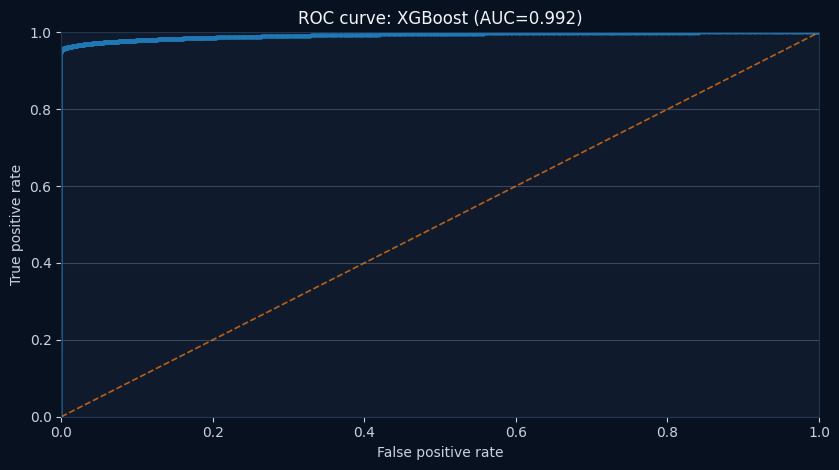

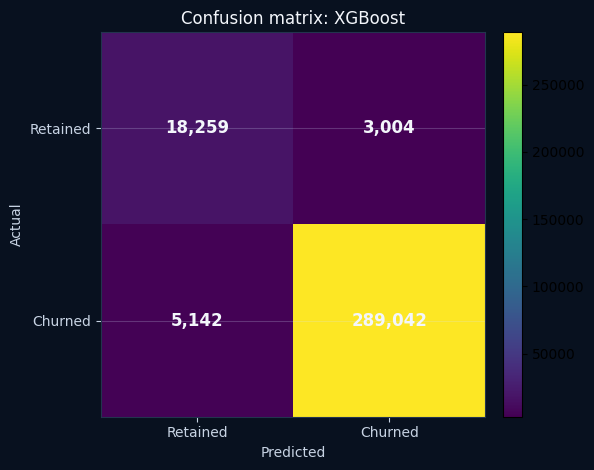

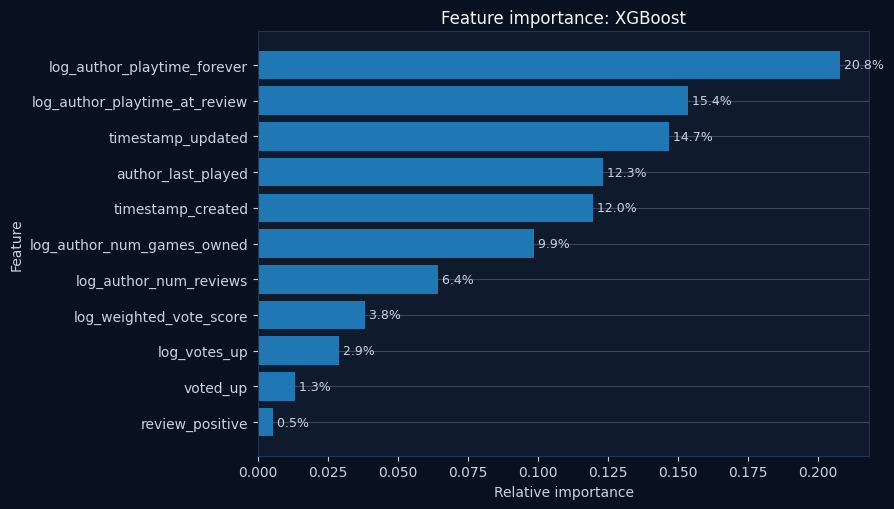

ML XGBoost took: 1141.83 seconds


In [13]:
# ------------------------------------------------------------
# Plot model-specific diagnostics
# ------------------------------------------------------------

xgb_auc_roc = (
    metrics_df
    .query("model == 'xgb' and metric == 'areaUnderROC'")
    ["test"]
    .iloc[0]
)

fig_roc = ml.plot_roc_curve(
    roc_df=xgb_roc_df,
    model_name="xgb",
    auc_roc=xgb_auc_roc,
    dark=True,
)

fig_cm = ml.plot_confusion_matrix(
    cm_df=xgb_cm_df,
    model_name="xgb",
    dark=True,
)

fig_importance = ml.plot_feature_importance(
    importance_df=xgb_importance_df,
    model_name="xgb",
    top_n=15,
    dark=True,
)

elapsed = time.time() - start
print(f"ML XGBoost took: {elapsed:.2f} seconds")

In [12]:
metrics_df = xgb_results["metrics_df"]
presentation_metrics = xgb_results["presentation_metrics"]
metric_rows = xgb_results["metric_rows"]

xgb_bundle = xgb_results["predictions"]["xgb"]
xgb_model = xgb_bundle["model"]
xgb_train_pred = xgb_bundle["train_pred"]
xgb_val_pred = xgb_bundle["test_pred"]

print(metrics_df)
print()

print(presentation_metrics)
print()

  model             metric     train      test  gap_train_minus_test  \
0   xgb       areaUnderROC  0.992737  0.992357              0.000381   
1   xgb        areaUnderPR  0.999481  0.999458              0.000023   
2   xgb                 f1  0.975289  0.974747              0.000542   
3   xgb  weightedPrecision  0.976177  0.975596              0.000581   
4   xgb     weightedRecall  0.974707  0.974176              0.000531   
5   xgb           accuracy  0.974707  0.974176              0.000531   

   train_time_sec  
0      121.005552  
1      121.005552  
2      121.005552  
3      121.005552  
4      121.005552  
5      121.005552  

metric model  accuracy  areaUnderPR  areaUnderROC        f1  \
0        xgb  0.974176     0.999458      0.992357  0.974747   

metric  weightedPrecision  weightedRecall  
0                0.975596        0.974176  



In [15]:
print(xgb_roc_df)
print()

print(xgb_cm_df)
print()

print(xgb_importance_df)
print()

          fpr       tpr  threshold_bin
0    0.000000  0.000000           1000
1    0.000000  0.948784            999
2    0.000000  0.948940            998
3    0.000000  0.949484            997
4    0.000000  0.950113            996
..        ...       ...            ...
989  0.998730  1.000000             11
990  0.999436  1.000000             10
991  0.999812  1.000000              9
992  1.000000  1.000000              8
993  1.000000  1.000000             -1

[994 rows x 3 columns]

Predicted  Retained  Churned
Actual                      
Retained      18259     3004
Churned        5142   289042

                          feature  importance
0     log_author_playtime_forever    0.208018
1   log_author_playtime_at_review    0.153752
2               timestamp_updated    0.146663
3              author_last_played    0.123197
4               timestamp_created    0.119775
5      log_author_num_games_owned    0.098509
6          log_author_num_reviews    0.064287
7         log_weighted

In [18]:
import pandas as pd

def write_dataframe_to_csv(df: pd.DataFrame, file_path: str, **kwargs):
    """
    Writes a Pandas DataFrame to a CSV file.

    Args:
        df (pd.DataFrame): The DataFrame to write.
        file_path (str): The path to the output CSV file.
        **kwargs: Additional keyword arguments to pass to df.to_csv().
    """
    try:
        df.to_csv(file_path, index=False, **kwargs)
        print(f"DataFrame successfully written to {file_path}")
    except Exception as e:
        print(f"Error writing DataFrame to CSV: {e}")

In [20]:
write_dataframe_to_csv(xgb_importance_df, file_path="xgb_importance.csv")

DataFrame successfully written to xgb_importance.csv


In [ ]:
spark.stop()